**Downloading the Dataset**

In [1]:
# Downloading Dataset
import os
import requests
from zipfile import ZipFile

# Define the destination directory
dataset_url = "https://www.kaggle.com/api/v1/datasets/download/ambarish/breakhis?dataset_version_number=4"
dataset_zip_path = "/content/BreakHis.zip"
dataset_extraction_path = "/content/BreakHis"

# Function to download the dataset
def download_dataset(url, save_path):
    print(f"Downloading dataset from {url}...")
    response = requests.get(url, stream=True)
    if response.status_code == 200:
        with open(save_path, "wb") as f:
            f.write(response.content)
        print("Download complete.")
    else:
        print(f"Failed to download dataset. Status code: {response.status_code}")

# Function to extract the dataset
def extract_dataset(zip_path, extraction_path):
    print(f"Extracting dataset to {extraction_path}...")
    with ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extraction_path)
    print("Extraction complete.")

# Ensure dataset directory exists
os.makedirs(dataset_extraction_path, exist_ok=True)

# Download and extract the dataset
download_dataset(dataset_url, dataset_zip_path)
extract_dataset(dataset_zip_path, dataset_extraction_path)

# Verify the files
print("Dataset contents:")
for root, dirs, files in os.walk(dataset_extraction_path):
    print(f"Directory: {root}")
    for file in files:
        print(f"  File: {file}")


Streaming output truncated to the last 5000 lines.
Directory: /content/BreakHis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/papillary_carcinoma/SOB_M_PC_14-9146
Directory: /content/BreakHis/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant/SOB/papillary_carcinoma/SOB_M_PC_14-9146/100X
  File: SOB_M_PC-14-9146-100-010.png
  File: SOB_M_PC-14-9146-100-011.png
  File: SOB_M_PC-14-9146-100-015.png
  File: SOB_M_PC-14-9146-100-007.png
  File: SOB_M_PC-14-9146-100-002.png
  File: SOB_M_PC-14-9146-100-005.png
  File: SOB_M_PC-14-9146-100-006.png
  File: SOB_M_PC-14-9146-100-019.png
  File: SOB_M_PC-14-9146-100-016.png
  File: SOB_M_PC-14-9146-100-018.png
  File: SOB_M_PC-14-9146-100-001.png
  File: SOB_M_PC-14-9146-100-012.png
  File: SOB_M_PC-14-9146-100-017.png
  File: SOB_M_PC-14-9146-100-013.png
  File: SOB_M_PC-14-9146-100-014.png
  File: SOB_M_PC-14-9146-100-021.png
  File: SOB_M_PC-14-9146-100-020.png
  File: SOB_M_PC-14-9146-100-003.png
  File: SOB_M_PC-14-91

**Dataset Information**

Total number of benign images: 2486
Total number of malignant images: 5435
Total number of images: 7921


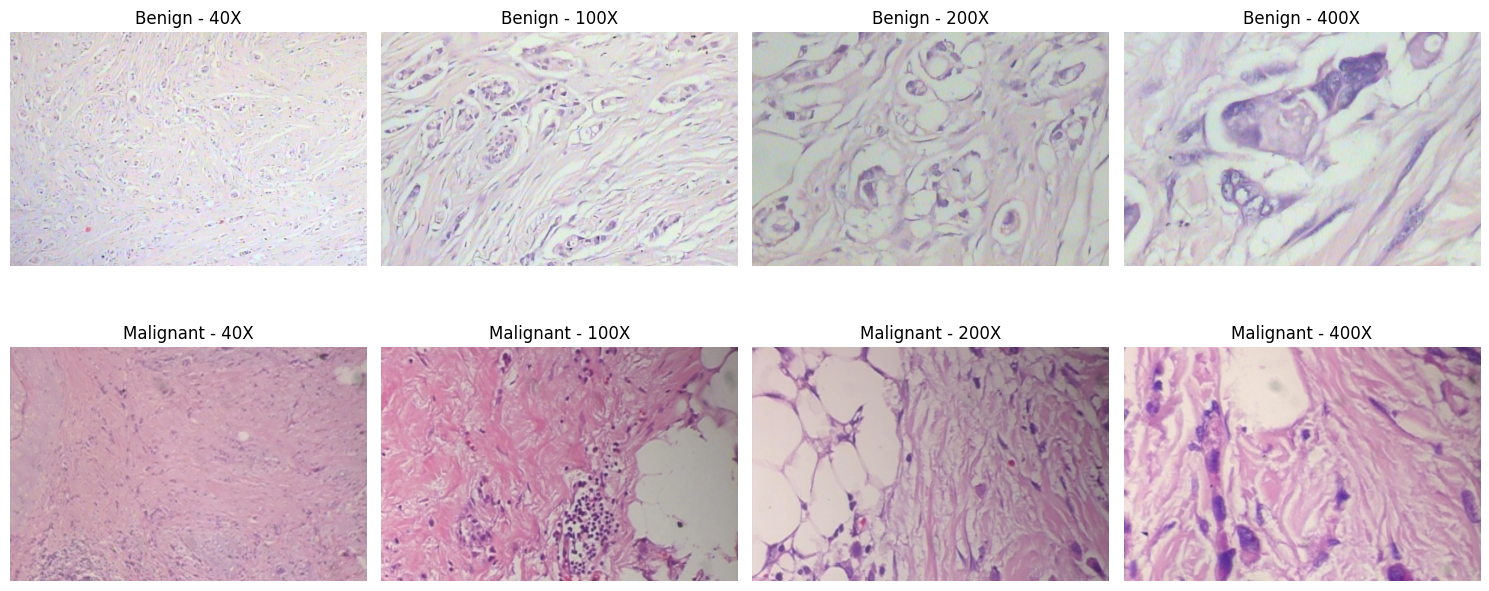

In [2]:
# Dataset Information
import os
import matplotlib.pyplot as plt
from PIL import Image

# Define dataset base path
dataset_path = "/content/BreakHis"
# Count total number of images
# Initialize counters
benign_count = 0
malignant_count = 0

# Traverse the dataset directory
for root, dirs, files in os.walk(dataset_path):
    if "benign" in root:
        benign_count += len(files)
    elif "malignant" in root:
        malignant_count += len(files)

# Calculate total images
total_images = benign_count + malignant_count

# Print the counts
print(f"Total number of benign images: {benign_count}")
print(f"Total number of malignant images: {malignant_count}")
print(f"Total number of images: {total_images}")

# Function to display one benign and one malignant image across magnifications
def display_sample_images(base_path):
    magnifications = ["40X", "100X", "200X", "400X"]
    benign_images = [None] * 4
    malignant_images = [None] * 4

    for root, dirs, files in os.walk(base_path):
        for file in files:
            for i, mag in enumerate(magnifications):
                if mag in root:
                    if "benign" in root and benign_images[i] is None:
                        benign_images[i] = os.path.join(root, file)
                    elif "malignant" in root and malignant_images[i] is None:
                        malignant_images[i] = os.path.join(root, file)

    # Display images
    fig, axs = plt.subplots(2, 4, figsize=(15, 8))
    #fig.suptitle("Benign and Malignant Images Across Magnifications", fontsize=16)

    # Benign images
    for i, img_path in enumerate(benign_images):
        if img_path:
            img = Image.open(img_path)
            axs[0, i].imshow(img)
            axs[0, i].set_title(f"Benign - {magnifications[i]}")
            axs[0, i].axis("off")

    # Malignant images
    for i, img_path in enumerate(malignant_images):
        if img_path:
            img = Image.open(img_path)
            axs[1, i].imshow(img)
            axs[1, i].set_title(f"Malignant - {magnifications[i]}")
            axs[1, i].axis("off")

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Display one image from each magnification for benign and malignant
display_sample_images(dataset_path)


**Preprocessing Steps**

In [3]:
# Preprocessing and Data Augmentation
import os
import random
from PIL import Image
from torchvision import transforms
from tqdm import tqdm

# Paths
original_dataset_path = "/content/BreakHis"
processed_dataset_path = "/content/BreakHis_Processed"

# Create processed directory if not exists
os.makedirs(processed_dataset_path, exist_ok=True)

# Augmentation Transforms
augmentation_transforms = [
    transforms.RandomHorizontalFlip(p=1.0),
    transforms.RandomVerticalFlip(p=1.0),
    transforms.RandomRotation(degrees=45),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
]

# Resize
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
])

# Function to apply augmentations
def augment_and_save(img_path, save_dir, augment_times=3):
    img = Image.open(img_path).convert('RGB')

    # Save original
    img_resized = basic_transform(img)
    img_resized.save(save_dir)

    # Apply augmentations and save
    for i in range(augment_times):
        aug = random.choice(augmentation_transforms)
        img_aug = aug(img)
        img_aug_resized = basic_transform(img_aug)

        # Create new filename
        base_name = os.path.splitext(os.path.basename(save_dir))[0]
        ext = os.path.splitext(save_dir)[1]
        new_filename = f"{base_name}_aug{i}{ext}"

        # Save augmented image
        img_aug_resized.save(os.path.join(os.path.dirname(save_dir), new_filename))

# Counters
benign_count = 0
malignant_count = 0

# Walk through original dataset
for root, dirs, files in os.walk(original_dataset_path):
    for file in tqdm(files):
        if file.lower().endswith(('png', 'jpg', 'jpeg')):
            # Full path to image
            img_path = os.path.join(root, file)

            # Detect class from folder name
            relative_path = os.path.relpath(root, original_dataset_path)
            class_name = relative_path.split(os.sep)[0].lower()  # assuming BreakHis/<benign>/ or <malignant>/

            # Create corresponding save path
            save_folder = os.path.join(processed_dataset_path, relative_path)
            os.makedirs(save_folder, exist_ok=True)
            save_path = os.path.join(save_folder, file)

            # Augment and Save
            augment_and_save(img_path, save_path, augment_times=3)

            # Each image will have (1 original + 3 augmented) = 4 images
            if "benign" in class_name:
                benign_count += 4
            elif "malignant" in class_name:
                malignant_count += 4

# Final Output
total_images = benign_count + malignant_count



100%|██████████| 1/1 [00:00<00:00, 8886.24it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 6/6 [00:00<00:00, 72108.38it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 16/16 [00:02<00:00,  6.49it/s]
0it [00:00, ?it/s]
100%|██████████| 16/16 [00:01<00:00,  9.27it/s]
0it [00:00, ?it/s]
100%|██████████| 17/17 [00:01<00:00,  9.57it/s]
0it [00:00, ?it/s]
100%|██████████| 23/23 [00:02<00:00,  9.96it/s]
0it [00:00, ?it/s]
100%|██████████| 12/12 [00:01<00:00, 10.01it/s]
0it [00:00, ?it/s]
100%|██████████| 21/21 [00:02<00:00,  7.84it/s]
0it [00:00, ?it/s]
100%|██████████| 35/35 [00:03<00:00,  8.83it/s]
0it [00:00, ?it/s]
0it [00:00, ?it/s]
100%|██████████| 29/29 [00:03<00:00,  7.62it/s]
0it [00:00, ?it/s]
100%|██████████| 38/38 [00:04<00:00,  8.46it/s]
0it [00:00, ?it/s]
100%|██████████| 18/18 [00:01<00:00, 10.32it/s]
0it [00:00, ?it/s]
100%|██████████| 18/18 [00:01<00:00,  9.63it/s]
0it [00:00, ?it/s]
100%|██████████| 32/32 [00:03<00:

**Putting data in Hierarcy**

In [4]:
# Data Structure into Proper Category, Benign, Malignant
import os

# Paths
benign_path = "/content/BreakHis_Processed/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/benign"
malignant_path = "/content/BreakHis_Processed/BreaKHis_v1/BreaKHis_v1/histology_slides/breast/malignant"

# Counters
benign_image_count = 0
malignant_image_count = 0

# Function to count images in a given path
def count_images_in_folder(folder_path):
    count = 0
    for root, dirs, files in os.walk(folder_path):
        for file in files:
            if file.lower().endswith(('png', 'jpg', 'jpeg')):
                count += 1
    return count

# Count images
benign_image_count = count_images_in_folder(benign_path)
malignant_image_count = count_images_in_folder(malignant_path)

# Total images
total_images = benign_image_count + malignant_image_count

# Print results
#print(f"Total number of benign images: {benign_image_count}")
#print(f"Total number of malignant images: {malignant_image_count}")
#print(f"Total number of images: {total_images}")


**Model Development**

In [ ]:
# =========================
# CNN BASELINE
# =========================
!pip -q install torch torchvision scikit-learn tqdm

import os, copy, random, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

# -------------------------
# Speed settings
# -------------------------
torch.backends.cudnn.benchmark = True

# -------------------------
# Config
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = "/content/BreakHis_Processed/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"

IMG_SIZE = 96                         # smaller = faster
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
NUM_WORKERS = 2
EPOCHS = 3                           # fewer epochs = much faster
PATIENCE = 1                         # early stop quickly if val doesn't improve

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

print("Device:", DEVICE)
print("IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE)

# -------------------------
# Dataset wrapper
# -------------------------
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# Faster transforms
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -------------------------
# Load dataset
# -------------------------
base_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
print("Classes:", base_dataset.classes)
print("Total images:", len(base_dataset))

targets = base_dataset.targets
indices = list(range(len(base_dataset)))

train_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=targets
)
train_targets = [targets[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.15, random_state=SEED, stratify=train_targets
)

train_ds = TransformSubset(base_dataset, train_idx, train_transform)
val_ds   = TransformSubset(base_dataset, val_idx, test_transform)
test_ds  = TransformSubset(base_dataset, test_idx, test_transform)

# -------------------------
# Weighted sampler
# -------------------------
train_labels = [base_dataset.targets[i] for i in train_idx]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[y] for y in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

loader_kwargs = {
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
}

if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    **loader_kwargs
)
val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)
test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    **loader_kwargs
)

# -------------------------
# Model
# -------------------------
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = backbone.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(1280, 1)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        x = self.classifier(x)
        return x

model = CNNModel().to(DEVICE)

# Freeze almost everything for speed
for p in model.features.parameters():
    p.requires_grad = False

# Unfreeze only the very last block
for p in model.features[18].parameters():
    p.requires_grad = True

print("Trainable params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

# -------------------------
# Train utilities
# -------------------------
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                              lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

def evaluate(model, loader):
    model.eval()
    losses = []
    all_preds, all_targets = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.float().unsqueeze(1).to(DEVICE, non_blocking=True)

            with torch.cuda.amp.autocast(enabled=USE_AMP):
                logits = model(x)
                loss = criterion(logits, y)

            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).long().cpu().numpy().ravel()
            targs = y.long().cpu().numpy().ravel()

            losses.append(loss.item())
            all_preds.extend(preds.tolist())
            all_targets.extend(targs.tolist())

    acc = accuracy_score(all_targets, all_preds)
    return np.mean(losses), acc, all_targets, all_preds

# -------------------------
# Training
# -------------------------
best_acc = 0.0
best_state = copy.deepcopy(model.state_dict())
no_improve = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    pbar = tqdm(train_loader, desc=f"Fast CNN Epoch {epoch+1}/{EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = y.float().unsqueeze(1).to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    train_loss = running_loss / len(train_loader)
    val_loss, val_acc, _, _ = evaluate(model, val_loader)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

    if val_acc > best_acc:
        best_acc = val_acc
        best_state = copy.deepcopy(model.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print("Early stopping triggered.")
            break

model.load_state_dict(best_state)

# -------------------------
# Test
# -------------------------
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader)
print(f"\nFast CNN Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"]))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Device: cpu
IMG_SIZE: 96 | BATCH_SIZE: 16
Classes: ['benign', 'malignant']
Total images: 31636
Trainable params: 413441


/tmp/ipykernel_360/915265054.py:176: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fast CNN Epoch 1/3:   0%|          | 0/1429 [00:00<?, ?it/s]

/tmp/ipykernel_360/915265054.py:220: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_360/915265054.py:187: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 1: train_loss=0.4171 | val_loss=0.3147 | val_acc=0.8733


Fast CNN Epoch 2/3:   0%|          | 0/1429 [00:00<?, ?it/s]

/tmp/ipykernel_360/915265054.py:220: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):
/tmp/ipykernel_360/915265054.py:187: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


Epoch 2: train_loss=0.3561 | val_loss=0.3135 | val_acc=0.8713
Early stopping triggered.


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/tmp/ipykernel_360/915265054.py:187: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):



Fast CNN Test Accuracy: 88.26%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.78      0.87      0.82      1488
   Malignant       0.94      0.89      0.91      3258

    accuracy                           0.88      4746
   macro avg       0.86      0.88      0.87      4746
weighted avg       0.89      0.88      0.88      4746

Confusion Matrix:
[[1296  192]
 [ 365 2893]]


**GAN**

In [ ]:
# =========================
# GAN MODEL
# =========================
!pip -q install torch torchvision scikit-learn tqdm

import os, copy, random, numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
from tqdm.auto import tqdm

torch.backends.cudnn.benchmark = True

# -------------------------
# Config
# -------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DATA_DIR = "/content/BreakHis_Processed/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"
IMG_SIZE = 96
BATCH_SIZE = 64 if torch.cuda.is_available() else 16
NUM_WORKERS = 2
LATENT_DIM = 32
NUM_CLASSES = 2
EPOCHS = 3
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE)

# -------------------------
# Dataset wrapper
# -------------------------
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = indices
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, label

# -------------------------
# Transform
# -------------------------
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# -------------------------
# Load data
# -------------------------
base_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
print("Classes:", base_dataset.classes)
print("Total images:", len(base_dataset))

targets = base_dataset.targets
indices = list(range(len(base_dataset)))

train_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=targets
)
train_targets = [targets[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.15, random_state=SEED, stratify=train_targets
)

train_ds = TransformSubset(base_dataset, train_idx, transform)
val_ds   = TransformSubset(base_dataset, val_idx, transform)
test_ds  = TransformSubset(base_dataset, test_idx, transform)

# -------------------------
# Balanced sampler
# -------------------------
train_labels = [base_dataset.targets[i] for i in train_idx]
class_counts = np.bincount(train_labels)
class_weights = 1.0 / class_counts
sample_weights = [class_weights[y] for y in train_labels]
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": True,
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_loader = DataLoader(train_ds, sampler=sampler, **loader_kwargs)
val_loader   = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader  = DataLoader(test_ds, shuffle=False, **loader_kwargs)

# -------------------------
# Generator
# -------------------------
class Generator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, z_dim)
        self.init_size = IMG_SIZE // 8
        self.fc = nn.Linear(z_dim * 2, 128 * self.init_size * self.init_size)

        self.net = nn.Sequential(
            nn.BatchNorm2d(128),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        y = self.label_emb(labels)
        x = torch.cat([z, y], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 128, self.init_size, self.init_size)
        return self.net(x)

# -------------------------
# Fixed discriminator/classifier
# Class prediction uses image features only
# -------------------------
class DiscriminatorClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )

        feat_dim = 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        self.adv_head = nn.Linear(feat_dim, 1)   # real/fake
        self.cls_head = nn.Linear(feat_dim, 1)   # benign/malignant

    def forward(self, img):
        feat = self.features(img).flatten(1)
        adv = self.adv_head(feat)
        cls = self.cls_head(feat)
        return adv, cls, feat

G = Generator().to(DEVICE)
D = DiscriminatorClassifier().to(DEVICE)

print("Generator params:", sum(p.numel() for p in G.parameters() if p.requires_grad))
print("Discriminator params:", sum(p.numel() for p in D.parameters() if p.requires_grad))

# -------------------------
# Losses and optimizers
# -------------------------
bce = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

# -------------------------
# Evaluation
# -------------------------
def evaluate_classifier(D_model, loader):
    D_model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = y.float().unsqueeze(1).to(DEVICE, non_blocking=True)

            _, cls_logits, _ = D_model(x)
            probs = torch.sigmoid(cls_logits)
            preds = (probs > 0.5).long().cpu().numpy().ravel()
            targs = y.long().cpu().numpy().ravel()

            all_preds.extend(preds.tolist())
            all_targets.extend(targs.tolist())

    acc = accuracy_score(all_targets, all_preds)
    return acc, all_targets, all_preds

# -------------------------
# Train
# -------------------------
best_val_acc = 0.0
best_state = copy.deepcopy(D.state_dict())
patience = 1
no_improve = 0

for epoch in range(EPOCHS):
    G.train()
    D.train()
    pbar = tqdm(train_loader, desc=f"Fixed Fast GAN Epoch {epoch+1}/{EPOCHS}", leave=False)

    for real_imgs, labels in pbar:
        real_imgs = real_imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        bs = real_imgs.size(0)

        real_target = torch.ones(bs, 1, device=DEVICE)
        fake_target = torch.zeros(bs, 1, device=DEVICE)
        cls_target = labels.float().unsqueeze(1)

        # -----------------
        # Train D
        # -----------------
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, labels)

        opt_D.zero_grad(set_to_none=True)

        real_adv, real_cls, _ = D(real_imgs)
        fake_adv, fake_cls, _ = D(fake_imgs.detach())

        # real/fake loss + class loss on real images
        d_loss_real = bce(real_adv, real_target)
        d_loss_fake = bce(fake_adv, fake_target)
        d_cls_real  = bce(real_cls, cls_target)

        # optional weak class supervision on fake images
        d_cls_fake  = bce(fake_cls, cls_target)

        d_loss = d_loss_real + d_loss_fake + 1.0 * d_cls_real + 0.2 * d_cls_fake
        d_loss.backward()
        opt_D.step()

        # -----------------
        # Train G
        # -----------------
        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, labels)

        opt_G.zero_grad(set_to_none=True)

        fake_adv, fake_cls, _ = D(fake_imgs)
        g_adv_loss = bce(fake_adv, real_target)
        g_cls_loss = bce(fake_cls, cls_target)

        g_loss = g_adv_loss + 0.5 * g_cls_loss
        g_loss.backward()
        opt_G.step()

        pbar.set_postfix(
            d_loss=f"{d_loss.item():.4f}",
            g_loss=f"{g_loss.item():.4f}"
        )

    val_acc, _, _ = evaluate_classifier(D, val_loader)
    print(f"Epoch {epoch+1}: val_acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_state = copy.deepcopy(D.state_dict())
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print("Early stopping triggered.")
            break

D.load_state_dict(best_state)

# -------------------------
# Final test
# -------------------------
test_acc, y_true, y_pred = evaluate_classifier(D, test_loader)

print(f"\nFixed Fast GAN Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"], zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Device: cpu
IMG_SIZE: 96 | BATCH_SIZE: 16
Classes: ['benign', 'malignant']
Total images: 31636
Generator params: 1291715
Discriminator params: 202850


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Fixed Fast GAN Epoch 1/3:   0%|          | 0/1429 [00:00<?, ?it/s]

Epoch 1: val_acc=0.6120


Fixed Fast GAN Epoch 2/3:   0%|          | 0/1429 [00:00<?, ?it/s]

Epoch 2: val_acc=0.7965


Fixed Fast GAN Epoch 3/3:   0%|          | 0/1429 [00:00<?, ?it/s]

Epoch 3: val_acc=0.8143


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Fixed Fast GAN Test Accuracy: 82.43%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.84      0.54      0.66      1488
   Malignant       0.82      0.95      0.88      3258

    accuracy                           0.82      4746
   macro avg       0.83      0.75      0.77      4746
weighted avg       0.83      0.82      0.81      4746

Confusion Matrix:
[[ 801  687]
 [ 147 3111]]


**CNN-cGAN**

In [5]:
# =========================
# IMPROVED CNN-cGAN: SSL + cGAN + feature fusion
#Proposed
# =========================
!pip -q install torch torchvision scikit-learn tqdm

import os, copy, random, numpy as np
from contextlib import nullcontext
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms, models
from tqdm.auto import tqdm

# -------------------------

# -------------------------
torch.backends.cudnn.benchmark = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -------------------------
# Config
# -------------------------
DATA_DIR = "/content/BreakHis_Processed/BreaKHis_v1/BreaKHis_v1/histology_slides/breast"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()

IMG_SIZE = 112 if torch.cuda.is_available() else 104
BATCH_SIZE = 40 if torch.cuda.is_available() else 10
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

LATENT_DIM = 32
NUM_CLASSES = 2

SSL_EPOCHS = 2
CGAN_EPOCHS = 3
CLS_EPOCHS = 11

SYNTH_PER_CLASS = 260
SSL_MAX_SAMPLES = 8000
CGAN_MAX_SAMPLES = 1200 if not torch.cuda.is_available() else 3500
TTA_EVAL = True

print("Device:", DEVICE)
print("IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE, "| NUM_WORKERS:", NUM_WORKERS)

scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
autocast_ctx = (lambda: torch.amp.autocast("cuda", enabled=USE_AMP)) if USE_AMP else nullcontext

# -------------------------
# Dataset helpers
# -------------------------
class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, label = self.dataset[self.indices[idx]]
        if self.transform:
            img = self.transform(img)
        return img, int(label)

class ContrastiveDataset(Dataset):
    def __init__(self, dataset, indices, tf1, tf2):
        self.dataset = dataset
        self.indices = list(indices)
        self.tf1 = tf1
        self.tf2 = tf2

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        img, _ = self.dataset[self.indices[idx]]
        return self.tf1(img), self.tf2(img)

class SyntheticTensorDataset(Dataset):
    def __init__(self, images, labels):
        self.images = images
        self.labels = np.asarray(labels, dtype=np.int64)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.images[idx], int(self.labels[idx])

class CombinedDataset(Dataset):
    def __init__(self, ds1, ds2):
        self.ds1 = ds1
        self.ds2 = ds2

    def __len__(self):
        return len(self.ds1) + len(self.ds2)

    def __getitem__(self, idx):
        if idx < len(self.ds1):
            return self.ds1[idx]
        return self.ds2[idx - len(self.ds1)]

# -------------------------
# Transforms
# -------------------------
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.08, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

ssl_transform_1 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.78, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.10, 0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

ssl_transform_2 = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.78, 1.0)),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(0.15, 0.15, 0.10, 0.02),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3),
])

# -------------------------
# Load data
# -------------------------
base_dataset = datasets.ImageFolder(DATA_DIR, transform=None)
print("Classes:", base_dataset.classes)
print("Total images:", len(base_dataset))

targets = base_dataset.targets
indices = np.arange(len(base_dataset))

train_idx, test_idx = train_test_split(
    indices, test_size=0.15, random_state=SEED, stratify=targets
)
train_targets = [targets[i] for i in train_idx]
train_idx, val_idx = train_test_split(
    train_idx, test_size=0.15, random_state=SEED, stratify=train_targets
)

train_idx = np.array(train_idx)
val_idx = np.array(val_idx)
test_idx = np.array(test_idx)

train_ds_aug = TransformSubset(base_dataset, train_idx, train_transform)
train_ds_plain = TransformSubset(base_dataset, train_idx, test_transform)
val_ds = TransformSubset(base_dataset, val_idx, test_transform)
test_ds = TransformSubset(base_dataset, test_idx, test_transform)

ssl_idx = np.random.choice(train_idx, size=min(SSL_MAX_SAMPLES, len(train_idx)), replace=False)
cgan_idx = np.random.choice(train_idx, size=min(CGAN_MAX_SAMPLES, len(train_idx)), replace=False)

ssl_ds = ContrastiveDataset(base_dataset, ssl_idx, ssl_transform_1, ssl_transform_2)
cgan_train_ds = TransformSubset(base_dataset, cgan_idx, test_transform)

# -------------------------
# Dataloaders
# -------------------------
loader_kwargs = {
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "pin_memory": torch.cuda.is_available(),
}
if NUM_WORKERS > 0:
    loader_kwargs["persistent_workers"] = True
    loader_kwargs["prefetch_factor"] = 2

train_labels_real = np.array([base_dataset.targets[i] for i in train_idx], dtype=np.int64)
class_counts_real = np.bincount(train_labels_real)
class_weights_real = 1.0 / np.maximum(class_counts_real, 1)
sample_weights_real = [class_weights_real[y] for y in train_labels_real]
real_sampler = WeightedRandomSampler(sample_weights_real, num_samples=len(sample_weights_real), replacement=True)

train_loader = DataLoader(train_ds_aug, sampler=real_sampler, **loader_kwargs)
train_plain_loader = DataLoader(train_ds_plain, shuffle=True, **loader_kwargs)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kwargs)
test_loader = DataLoader(test_ds, shuffle=False, **loader_kwargs)
ssl_loader = DataLoader(ssl_ds, shuffle=True, **loader_kwargs)
cgan_loader = DataLoader(cgan_train_ds, shuffle=True, **loader_kwargs)

# -------------------------
# cGAN
# -------------------------
class Generator(nn.Module):
    def __init__(self, z_dim=LATENT_DIM, num_classes=NUM_CLASSES):
        super().__init__()
        self.label_emb = nn.Embedding(num_classes, z_dim)
        self.init_size = IMG_SIZE // 8
        self.fc = nn.Linear(z_dim * 2, 128 * self.init_size * self.init_size)

        self.net = nn.Sequential(
            nn.BatchNorm2d(128),
            nn.Upsample(scale_factor=2),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(64, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(True),

            nn.Upsample(scale_factor=2),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Tanh()
        )

    def forward(self, z, labels):
        y = self.label_emb(labels)
        x = torch.cat([z, y], dim=1)
        x = self.fc(x)
        x = x.view(x.size(0), 128, self.init_size, self.init_size)
        return self.net(x)

class DiscriminatorClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(32, 64, 4, 2, 1),
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(64, 128, 4, 2, 1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
        )
        self.feat_dim = 128 * (IMG_SIZE // 8) * (IMG_SIZE // 8)
        self.adv_head = nn.Linear(self.feat_dim, 1)
        self.cls_head = nn.Linear(self.feat_dim, 1)

    def forward(self, x):
        feat = self.features(x).flatten(1)
        adv = self.adv_head(feat)
        cls = self.cls_head(feat)
        return adv, cls, feat

G = Generator().to(DEVICE)
D = DiscriminatorClassifier().to(DEVICE)

# -------------------------
# SSL backbone
# -------------------------
class SSLBackbone(nn.Module):
    def __init__(self):
        super().__init__()
        base = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        self.features = base.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.proj = nn.Sequential(
            nn.Linear(1280, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 64)
        )

    def encode(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return x

    def forward(self, x):
        h = self.encode(x)
        z = self.proj(h)
        z = F.normalize(z, dim=1)
        return h, z

ssl_model = SSLBackbone().to(DEVICE)

def nt_xent_loss(z1, z2, temperature=0.2):
    bs = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    sim = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=2)
    mask = torch.eye(2 * bs, dtype=torch.bool, device=z.device)
    sim = sim / temperature
    sim.masked_fill_(mask, -9e15)
    positives = torch.cat([torch.diag(sim, bs), torch.diag(sim, -bs)], dim=0)
    denominator = torch.logsumexp(sim, dim=1)
    return (-positives + denominator).mean()

# -------------------------
# Step 1: SSL
# -------------------------
ssl_opt = torch.optim.AdamW(ssl_model.parameters(), lr=2e-4, weight_decay=1e-4)

for epoch in range(SSL_EPOCHS):
    ssl_model.train()
    running = 0.0
    pbar = tqdm(ssl_loader, desc=f"SSL Epoch {epoch+1}/{SSL_EPOCHS}", leave=False)
    for x1, x2 in pbar:
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)

        ssl_opt.zero_grad(set_to_none=True)
        with autocast_ctx():
            _, z1 = ssl_model(x1)
            _, z2 = ssl_model(x2)
            loss = nt_xent_loss(z1, z2)

        scaler.scale(loss).backward()
        scaler.unscale_(ssl_opt)
        torch.nn.utils.clip_grad_norm_(ssl_model.parameters(), 1.0)
        scaler.step(ssl_opt)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    print(f"SSL Epoch {epoch+1}: loss={running/max(1,len(ssl_loader)):.4f}")

# -------------------------
# Step 2: cGAN
# -------------------------
bce = nn.BCEWithLogitsLoss()
opt_G = torch.optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = torch.optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

for epoch in range(CGAN_EPOCHS):
    G.train()
    D.train()
    pbar = tqdm(cgan_loader, desc=f"cGAN Epoch {epoch+1}/{CGAN_EPOCHS}", leave=False)

    for real_imgs, labels in pbar:
        real_imgs = real_imgs.to(DEVICE, non_blocking=True)
        labels = torch.as_tensor(labels, dtype=torch.long, device=DEVICE)
        bs = real_imgs.size(0)

        real_target = torch.ones(bs, 1, device=DEVICE)
        fake_target = torch.zeros(bs, 1, device=DEVICE)
        cls_target = labels.float().unsqueeze(1)

        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, labels)

        opt_D.zero_grad(set_to_none=True)
        real_adv, real_cls, _ = D(real_imgs)
        fake_adv, fake_cls, _ = D(fake_imgs.detach())

        d_loss = (
            bce(real_adv, real_target) +
            bce(fake_adv, fake_target) +
            1.0 * bce(real_cls, cls_target) +
            0.2 * bce(fake_cls, cls_target)
        )
        d_loss.backward()
        torch.nn.utils.clip_grad_norm_(D.parameters(), 1.0)
        opt_D.step()

        z = torch.randn(bs, LATENT_DIM, device=DEVICE)
        fake_imgs = G(z, labels)

        opt_G.zero_grad(set_to_none=True)
        fake_adv, fake_cls, _ = D(fake_imgs)
        g_loss = bce(fake_adv, real_target) + 0.5 * bce(fake_cls, cls_target)
        g_loss.backward()
        torch.nn.utils.clip_grad_norm_(G.parameters(), 1.0)
        opt_G.step()

        pbar.set_postfix(d_loss=f"{d_loss.item():.4f}", g_loss=f"{g_loss.item():.4f}")

# -------------------------
# Step 3: generate filtered synthetic data
# -------------------------
@torch.no_grad()
def generate_filtered_synthetic_images(generator, discriminator, num_per_class=SYNTH_PER_CLASS, overgen_factor=3):
    generator.eval()
    discriminator.eval()

    final_imgs = []
    final_labels = []

    for cls in [0, 1]:
        total_needed = num_per_class * overgen_factor
        all_imgs = []
        all_scores = []

        remaining = total_needed
        while remaining > 0:
            bs = min(BATCH_SIZE, remaining)
            z = torch.randn(bs, LATENT_DIM, device=DEVICE)
            labels = torch.full((bs,), cls, dtype=torch.long, device=DEVICE)
            fake = generator(z, labels)

            adv_logits, cls_logits, _ = discriminator(fake)
            adv_prob = torch.sigmoid(adv_logits).squeeze(1)
            cls_prob = torch.sigmoid(cls_logits).squeeze(1)
            cls_match = cls_prob if cls == 1 else (1.0 - cls_prob)

            score = 0.65 * adv_prob + 0.35 * cls_match

            all_imgs.append(fake.cpu())
            all_scores.append(score.cpu())
            remaining -= bs

        all_imgs = torch.cat(all_imgs, dim=0)
        all_scores = torch.cat(all_scores, dim=0)

        top_idx = torch.topk(all_scores, k=min(num_per_class, all_imgs.size(0)), largest=True).indices
        selected_imgs = all_imgs[top_idx]
        selected_labels = np.full((selected_imgs.size(0),), cls, dtype=np.int64)

        final_imgs.append(selected_imgs)
        final_labels.append(selected_labels)

    final_imgs = torch.cat(final_imgs, dim=0)
    final_labels = np.concatenate(final_labels, axis=0)
    return final_imgs, final_labels

synth_imgs, synth_labels = generate_filtered_synthetic_images(G, D, num_per_class=SYNTH_PER_CLASS, overgen_factor=3)
print("Synthetic images kept:", len(synth_labels))

synth_ds = SyntheticTensorDataset(synth_imgs, synth_labels)
combined_ds = CombinedDataset(train_ds_plain, synth_ds)

combined_labels = np.concatenate([train_labels_real, synth_labels], axis=0)
combined_counts = np.bincount(combined_labels)
combined_class_weights = 1.0 / np.maximum(combined_counts, 1)
combined_sample_weights = [combined_class_weights[y] for y in combined_labels]
combined_sampler = WeightedRandomSampler(combined_sample_weights, num_samples=len(combined_sample_weights), replacement=True)

combined_loader = DataLoader(combined_ds, sampler=combined_sampler, **loader_kwargs)

# -------------------------
# Step 4: CNN-cGAN with stronger fusion
# -------------------------
class ProposedCNNcGAN(nn.Module):
    def __init__(self, ssl_model, discriminator):
        super().__init__()

        self.cnn_encoder = ssl_model.features
        self.cnn_pool = nn.AdaptiveAvgPool2d(1)

        for p in self.cnn_encoder.parameters():
            p.requires_grad = False
        for idx in [16, 17, 18]:
            for p in self.cnn_encoder[idx].parameters():
                p.requires_grad = True

        self.discriminator = discriminator
        for p in self.discriminator.parameters():
            p.requires_grad = False

        disc_feat_dim = discriminator.feat_dim

        self.cnn_proj = nn.Sequential(
            nn.Linear(1280, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20)
        )

        self.disc_proj = nn.Sequential(
            nn.Linear(disc_feat_dim, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20)
        )

        self.gate = nn.Sequential(
            nn.Linear(512, 256),
            nn.Sigmoid()
        )

        self.classifier = nn.Sequential(
            nn.Linear(256 * 3, 320),
            nn.ReLU(inplace=True),
            nn.Dropout(0.35),
            nn.Linear(320, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.20),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        cnn_feat = self.cnn_encoder(x)
        cnn_feat = self.cnn_pool(cnn_feat).flatten(1)
        cnn_feat = self.cnn_proj(cnn_feat)

        _, _, disc_feat = self.discriminator(x)
        disc_feat = self.disc_proj(disc_feat)

        gate = self.gate(torch.cat([cnn_feat, disc_feat], dim=1))
        fused = gate * cnn_feat + (1.0 - gate) * disc_feat

        feat = torch.cat([cnn_feat, disc_feat, fused], dim=1)
        return self.classifier(feat)

model = ProposedCNNcGAN(ssl_model, D).to(DEVICE)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2.5e-4,
    weight_decay=1e-4
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=CLS_EPOCHS)

# -------------------------
# Inference helpers
# -------------------------
def predict_logits(model, x, use_tta=False):
    logits = model(x)
    if use_tta:
        x_h = torch.flip(x, dims=[3])
        x_v = torch.flip(x, dims=[2])
        x_hv = torch.flip(x, dims=[2, 3])
        logits = (logits + model(x_h) + model(x_v) + model(x_hv)) / 4.0
    return logits

def collect_probs(model, loader, use_tta=True):
    model.eval()
    all_probs, all_targets = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(DEVICE, non_blocking=True)
            y = torch.as_tensor(y, dtype=torch.float32, device=DEVICE).unsqueeze(1)

            with autocast_ctx():
                logits = predict_logits(model, x, use_tta=use_tta)
                probs = torch.sigmoid(logits)

            all_probs.extend(probs.cpu().numpy().ravel().tolist())
            all_targets.extend(y.cpu().numpy().ravel().astype(int).tolist())

    return np.array(all_probs), np.array(all_targets)

def evaluate_with_threshold(model, loader, threshold=0.5, use_tta=True):
    probs, targets = collect_probs(model, loader, use_tta=use_tta)
    preds = (probs > threshold).astype(int)
    acc = accuracy_score(targets, preds)
    return acc, targets.tolist(), preds.tolist()

def find_best_threshold(model, loader, use_tta=True):
    probs, targets = collect_probs(model, loader, use_tta=use_tta)
    best_thr, best_acc = 0.5, 0.0
    for thr in np.arange(0.35, 0.66, 0.01):
        preds = (probs > thr).astype(int)
        acc = accuracy_score(targets, preds)
        if acc > best_acc:
            best_acc = acc
            best_thr = float(thr)
    return best_thr, best_acc

# -------------------------
# Step 5: train classifier
# -------------------------
best_acc = 0.0
best_state = copy.deepcopy(model.state_dict())

for epoch in range(CLS_EPOCHS):
    model.train()
    running_loss = 0.0

    pbar = tqdm(combined_loader, desc=f"CNN-cGAN Epoch {epoch+1}/{CLS_EPOCHS}", leave=False)
    for x, y in pbar:
        x = x.to(DEVICE, non_blocking=True)
        y = torch.as_tensor(y, dtype=torch.float32, device=DEVICE).unsqueeze(1)

        optimizer.zero_grad(set_to_none=True)
        with autocast_ctx():
            logits = model(x)
            loss = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.4f}")

    scheduler.step()

    train_loss = running_loss / max(1, len(combined_loader))
    val_threshold, val_acc_thr = find_best_threshold(model, val_loader, use_tta=TTA_EVAL)
    print(f"Epoch {epoch+1}: train_loss={train_loss:.4f} | val_acc={val_acc_thr:.4f} | best_thr={val_threshold:.2f}")

    if val_acc_thr > best_acc:
        best_acc = val_acc_thr
        best_state = copy.deepcopy(model.state_dict())

model.load_state_dict(best_state)

# -------------------------
# Final threshold tuning on val
# -------------------------
best_threshold, best_val_acc = find_best_threshold(model, val_loader, use_tta=TTA_EVAL)
print(f"\nBest validation threshold: {best_threshold:.2f} | Best validation accuracy: {best_val_acc*100:.2f}%")

# -------------------------
# Final test
# -------------------------
test_acc, y_true, y_pred = evaluate_with_threshold(model, test_loader, threshold=best_threshold, use_tta=TTA_EVAL)

print(f"\nImproved CNN-cGAN Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["Benign", "Malignant"], zero_division=0))
print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

Device: cpu
IMG_SIZE: 104 | BATCH_SIZE: 10 | NUM_WORKERS: 0
Classes: ['benign', 'malignant']
Total images: 31636
Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 98.1MB/s]


SSL Epoch 1/2:   0%|          | 0/800 [00:00<?, ?it/s]

SSL Epoch 1: loss=0.2208


SSL Epoch 2/2:   0%|          | 0/800 [00:00<?, ?it/s]

...

Epoch 9: train_loss=0.1500 | val_acc=0.9541 | best_thr=0.44


CNN-cGAN Epoch 10/11:   0%|          | 0/2338 [00:00<?, ?it/s]

Epoch 10: train_loss=0.1343 | val_acc=0.9519 | best_thr=0.66


CNN-cGAN Epoch 11/11:   0%|          | 0/2338 [00:00<?, ?it/s]

Epoch 11: train_loss=0.1304 | val_acc=0.9536 | best_thr=0.66

Best validation threshold: 0.44 | Best validation accuracy: 95.41%

Improved CNN-cGAN Test Accuracy: 94.18%

Classification Report:
              precision    recall  f1-score   support

      Benign       0.91      0.90      0.91      1488
   Malignant       0.96      0.96      0.96      3258

    accuracy                           0.94      4746
   macro avg       0.93      0.93      0.93      4746
weighted avg       0.94      0.94      0.94      4746

Confusion Matrix:
[[1342  146]
 [ 130 3128]]


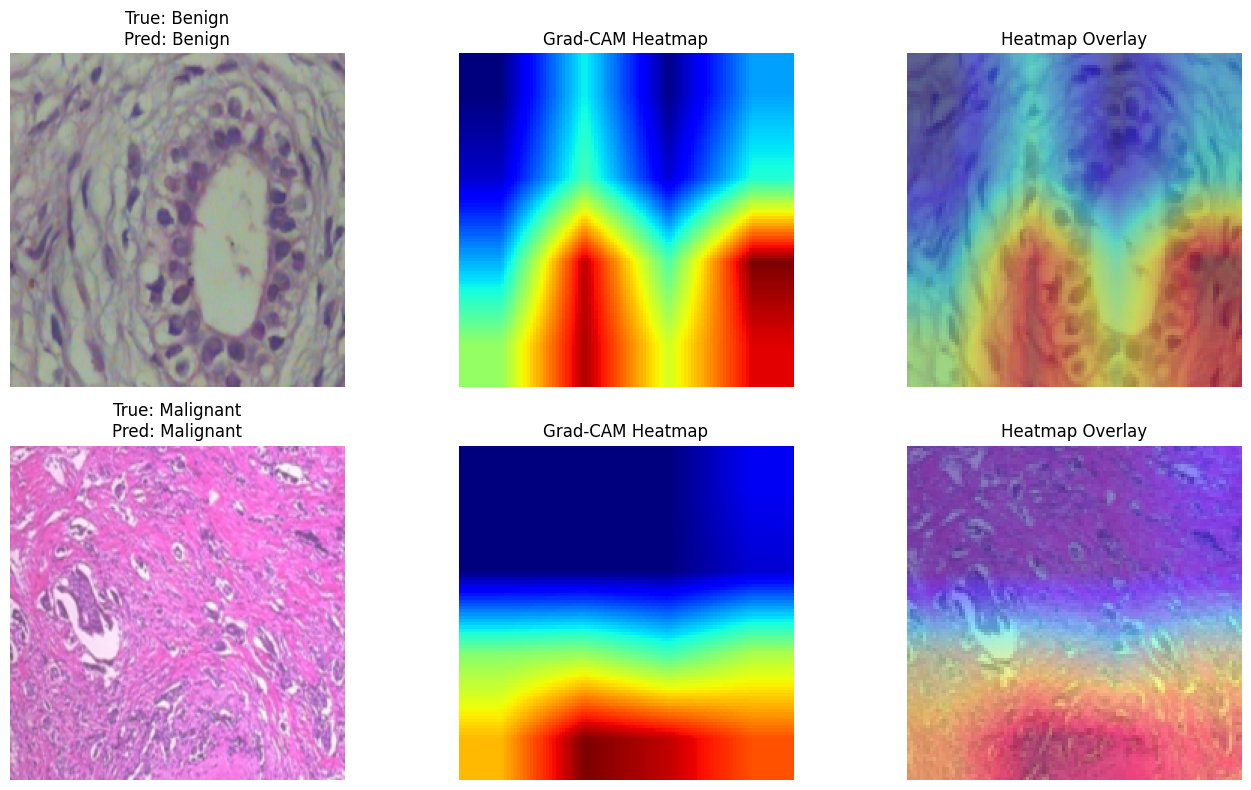

In [ ]:
# =========================
# Results VISUALIZATION
# show 1 random benign + 1 random malignant
# with true label, predicted label, and Grad-CAM heatmap
# =========================
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from PIL import Image
import torch
import torch.nn.functional as F

# -------------------------
# Make sure model is in eval mode
# -------------------------
model.eval()

class_names = base_dataset.classes  # ['benign', 'malignant']

# -------------------------
# Helper: get random test samples by class
# -------------------------
test_labels = [base_dataset.targets[i] for i in test_idx]

benign_candidates = [idx for idx, lbl in zip(test_idx, test_labels) if lbl == 0]
malignant_candidates = [idx for idx, lbl in zip(test_idx, test_labels) if lbl == 1]

benign_sample_idx = random.choice(benign_candidates)
malignant_sample_idx = random.choice(malignant_candidates)

selected_indices = [benign_sample_idx, malignant_sample_idx]

# -------------------------
# Helper: denormalize for display
# -------------------------
def denormalize(img_tensor):
    img = img_tensor.clone().cpu()
    img = img * 0.5 + 0.5
    img = torch.clamp(img, 0, 1)
    return img

# -------------------------
# Grad-CAM helper
# We use the last CNN feature block
# -------------------------
target_layer = model.cnn_encoder[18]

activations = None
gradients = None

def forward_hook(module, inp, out):
    global activations
    activations = out.detach()

def backward_hook(module, grad_in, grad_out):
    global gradients
    gradients = grad_out[0].detach()

forward_handle = target_layer.register_forward_hook(forward_hook)
backward_handle = target_layer.register_full_backward_hook(backward_hook)

def generate_gradcam(input_tensor):
    global activations, gradients

    model.zero_grad(set_to_none=True)
    logits = model(input_tensor)
    score = logits[:, 0]
    score.backward(torch.ones_like(score))

    # activations: [B, C, H, W]
    # gradients:   [B, C, H, W]
    weights = gradients.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activations).sum(dim=1, keepdim=True)
    cam = F.relu(cam)

    cam = F.interpolate(cam, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)
    cam = cam[0, 0].cpu().numpy()

    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    return cam

# -------------------------
# Visualization
# -------------------------
fig, axes = plt.subplots(len(selected_indices), 3, figsize=(14, 8))

if len(selected_indices) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, data_idx in enumerate(selected_indices):
    pil_img, true_label = base_dataset[data_idx]

    input_tensor = test_transform(pil_img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(input_tensor)
        prob = torch.sigmoid(logits).item()
        pred_label = 1 if prob > 0.5 else 0

    cam = generate_gradcam(input_tensor)

    # original transformed image for display
    disp_img = denormalize(test_transform(pil_img)).permute(1, 2, 0).numpy()

    # original PIL resized for overlay
    pil_resized = pil_img.resize((IMG_SIZE, IMG_SIZE))
    pil_arr = np.array(pil_resized).astype(np.float32) / 255.0

    # heatmap
    heatmap = cm.jet(cam)[..., :3]  # RGB only
    overlay = 0.55 * pil_arr + 0.45 * heatmap
    overlay = np.clip(overlay, 0, 1)

    title_text = (
        f"True: {class_names[true_label].capitalize()}\n"
        f"Pred: {class_names[pred_label].capitalize()}"
    )

    axes[row, 0].imshow(pil_img)
    axes[row, 0].set_title(f"{title_text}")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(cam, cmap="jet")
    axes[row, 1].set_title("Grad-CAM Heatmap")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(overlay)
    axes[row, 2].set_title("Heatmap Overlay")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

# cleanup hooks
forward_handle.remove()
backward_handle.remove()